# **[W3] TASK**

- 작업 챕터: 05-3장 트리의 앙상블

- 주요 질문:  
    1. 모델마다 성능과 연산 속도가 천차만별임. 상황에 따라 자원이 제한되므로 단순히 성능이 좋은 모델을 찾는게 아니라 어떤 모델을 첫 번째 기준(Baseline)으로 삼아야 성능 개선의 척도를 명확히 할 수 있는가?


In [ ]:
# 기본 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 데이터 전처리
wine = pd.read_csv("https://bit.ly/wine_csv_data")

data = wine[['alcohol', 'sugar', 'pH']]
target = wine['class']

train_input, test_input, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

## **1. 트리 모델**

### **1.1. RandomForestClassifier**

In [ ]:
# 교차검증(Cross_Validate)
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, random_state=42)

scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9973541965122431 0.8905151032797809


In [ ]:
# 특성 중요도
rf.fit(train_input, train_target)

print(rf.feature_importances_)

[0.23167441 0.50039841 0.26792718]


In [ ]:
#OOB 샘플
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)

rf.fit(train_input, train_target)

print(rf.oob_score_)

0.8934000384837406


### **1.2 ExtraTreeClassifier**

In [ ]:
# ExtraTree
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(n_jobs=-1, random_state=42)

scores = cross_validate(et, train_input, train_target,
                        return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9974503966084433 0.8887848893166506


In [ ]:
# 특성 중요도(et)
et.fit(train_input, train_target)

print(et.feature_importances_)

[0.20183568 0.52242907 0.27573525]


## **2. 앙상블 모델**

### **2.1. GradientBoosting**

In [ ]:
# GradientBoosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

scores = cross_validate(gb, train_input, train_target,
                        return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.8881086892152563 0.8720430147331015


In [ ]:
# GradientBoosting-2
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2,
                                random_state=42)

scores = cross_validate(gb, train_input, train_target,
                        return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9464595437171814 0.8780082549788999


In [ ]:
# 특성 중요도(gb)
gb.fit(train_input, train_target)

print(gb.feature_importances_)

[0.15887763 0.6799705  0.16115187]


### **2.2 Hist-GradientBoosting**

In [ ]:
# Histogram-based Gradient Boosting
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=42)

scores = cross_validate(hgb, train_input, train_target,
                        return_train_score=True)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9321723946453317 0.8801241948619236


In [ ]:
# Histogram-based Gradient Boosting-2
from sklearn.inspection import permutation_importance

hgb.fit(train_input, train_target)

result = permutation_importance(hgb, train_input, train_target,
                                n_repeats=10, random_state=42, n_jobs=-1)

print(result.importances_mean)

[0.08876275 0.23438522 0.08027708]


In [ ]:
# 성능 확인(hgb)
hgb.score(test_input, test_target)

0.8723076923076923

### **2.3 XGBoost**

In [ ]:
# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(tree_method='hist', random_state=42)

scores=cross_validate(xgb, train_input, train_target,
                      return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9567059184812372 0.8783915747390243


### **2.4 Lightgbm**

In [ ]:
# Lightgbm
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(random_state=42)

scores=cross_validate(lgb, train_input, train_target,
                      return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.935828414851749 0.8801251203079884


## **3. 자유 주제**

### **3.1 Baseline**
- `로지스틱 회귀`, `결정 트리`, `랜덤 포레스트`, `그래이디언트 부스팅`을 동일한 환경에서 비교하여, 각 모델이 베이스라인으로서 가지는 가치를 측정


[모델별 성능 비교 결과]


,Model,Train Score,Valid Score,Time (sec)
2,Random Forest (Strong Baseline),0.997354,0.890515,2.792907
3,Gradient Boosting (Complex),0.888109,0.872043,2.575270
1,Decision Tree (Non-linear),0.997450,0.855300,0.106807
0,Logistic Regression (Linear),0.777564,0.779491,0.116958



[모델별 성능 비교 결과:시각화]


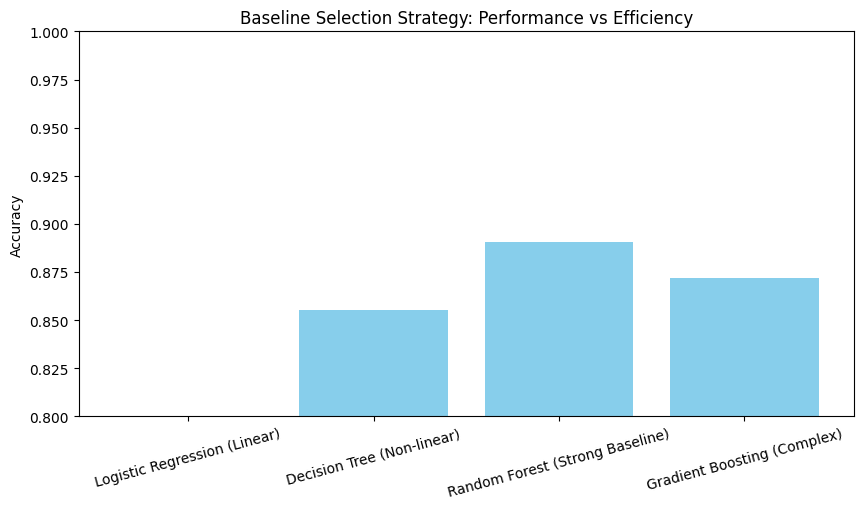

In [7]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. 데이터 준비 (W3 와인 데이터)
wine = pd.read_csv('https://bit.ly/wine_csv_data')
data = wine[['alcohol', 'sugar', 'pH']]
target = wine['class']
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42
)

# 2. 비교할 모델 설정
models = {
    'Logistic Regression (Linear)': LogisticRegression(),
    'Decision Tree (Non-linear)': DecisionTreeClassifier(random_state=42),
    'Random Forest (Strong Baseline)': RandomForestClassifier(n_jobs=-1, random_state=42),
    'Gradient Boosting (Complex)': GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    # 학습 시간 및 교차 검증 점수 측정
    start_time = time.time()
    cv_results = cross_validate(model, train_input, train_target,
                                return_train_score=True, cv=5)
    elapsed_time = time.time() - start_time

    results.append({
        'Model': name,
        'Train Score': np.mean(cv_results['train_score']),
        'Valid Score': np.mean(cv_results['test_score']),
        'Time (sec)': elapsed_time
    })

# 3. 결과 요약 및 시각화
df_res = pd.DataFrame(results)
print("\n[모델별 성능 비교 결과]")
display(df_res.sort_values(by='Valid Score', ascending=False))

# 시각화: 성능 대비 시간 효율성
print("\n[모델별 성능 비교 결과:시각화]")
plt.figure(figsize=(10, 5))
plt.bar(df_res['Model'], df_res['Valid Score'], color='skyblue', label='Valid Score')
plt.ylabel('Accuracy')
plt.title('Baseline Selection Strategy: Performance vs Efficiency')
plt.ylim(0.8, 1.0) # 차이를 명확히 보기 위해 범위 설정
plt.xticks(rotation=15)
plt.show()

- **하한선 설정**: 로지스틱 회귀는 가장 빠르지만 성능이 낮음. 이는 **최소한 이 점수보다는 높아야 모델을 개선할 가치가 있다는 성능의 하한선**이 됩니다.

- **랜덤 포레스트의 효율성**: 별도의 하이퍼파라미터 튜닝 없이도 랜덤 포레스트가 매우 높은 검증 점수를 기록함. 과대적합에도 강하므로, 정형 데이터 작업 시 가장 **'신뢰할 수 있는 첫 번째 기준점'**으로 적합

- **복잡한 모델의 기회비용**: 그레이디언트 부스팅은 학습 시간이 더 소요되지만, 기본 설정에서는 랜덤 포레스트와 큰 차이가 없거나 오히려 낮을 수 있음.

- **최종 전략**: 무조건 복잡한 모델(XGBoost, LightGBM 등)을 먼저 돌리기보다, 랜덤 포레스트를 베이스라인으로 세워 성능의 '바닥'을 확인한 뒤, 이를 유의미하게(예: 1% 이상) 넘어서기 위해 복잡한 기법을 도입하는 것이 적절